# 01. De transacciones sueltas a secuencias por remitente

**Detección de lavado de dinero en corredores de remesas**

Una transacción aislada dice muy poco sobre la intención de quien la envía. Lo que delata el lavado de dinero es el patrón a lo largo del tiempo, la frecuencia que se dispara, los montos que se fraccionan justo debajo de un umbral de reporte, los destinos que cambian de golpe. Por eso el primer problema de este proyecto no es modelar sino representar.

En este cuaderno se transforman transacciones individuales en secuencias ordenadas por remitente, y se documenta cada decisión que define esa representación. El resultado es un conjunto de tensores que el segundo cuaderno consume directamente.

**Preparación del entorno**

Se importan las librerías necesarias y se agrega la carpeta `src` a la ruta de búsqueda. El código funciona igual en una máquina local y en Google Colab, donde el repositorio se clona antes de empezar.

In [ ]:
import gc
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

# Se detecta si el modulo de Colab esta disponible, y no solo si ya fue
# importado, porque al conectar un editor externo al runtime de Colab el módulo
# existe aunque nadie lo haya cargado todavia.
EN_COLAB = importlib.util.find_spec("google.colab") is not None
REPOSITORIO = "https://github.com/Dcextrim/CC3092-Proyecto2.git"

if EN_COLAB:
    RAIZ = Path("/content/remittance-anomaly-detection")
    if RAIZ.exists():
        subprocess.run(["git", "-C", str(RAIZ), "pull", "-q"], check=False)
    else:
        subprocess.run(["git", "clone", "-q", REPOSITORIO, str(RAIZ)], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kagglehub"], check=True)
else:
    # Se sube desde el directorio actual hasta encontrar la raíz del proyecto,
    # de modo que la celda funcione igual si se vuelve a ejecutar.
    RAIZ = Path.cwd()
    while not (RAIZ / "src" / "utils" / "rutas.py").exists() and RAIZ != RAIZ.parent:
        RAIZ = RAIZ.parent

if not (RAIZ / "src" / "utils" / "rutas.py").exists():
    raise SystemExit(f"No se encontro el proyecto en {RAIZ}. Revise el clonado o la ruta.")

if str(RAIZ / "src") not in sys.path:
    sys.path.append(str(RAIZ / "src"))
os.chdir(RAIZ)

from utils.credenciales import configurar_kaggle

print("raiz del proyecto:", RAIZ)
print("credenciales de Kaggle listas:", configurar_kaggle())

raiz del proyecto: /content/remittance-anomaly-detection
credenciales de Kaggle listas: True


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data_pipeline import construir
from data_pipeline.preprocessing import features, secuencias, splits
from data_pipeline.sourcing.downloaders import descarga
from utils.config import obtener
from utils.visualizacion import set_estilo, mapa_secuencia, guardar

set_estilo()
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

print("numpy", np.__version__, "| pandas", pd.__version__)
print("longitud maxima:", obtener("secuencias.longitud_maxima"),
      "| minimo de transacciones:", obtener("secuencias.minimo_transacciones"),
      "| semilla:", obtener("particion.semilla"))

numpy 2.1.3 | pandas 2.2.3
longitud maxima: 32 | minimo de transacciones: 4 | semilla: 42


## 1. Origen de los datos

El proyecto usa dos conjuntos de datos públicos de Kaggle. **IBM Transactions for Anti Money Laundering** aporta las secuencias, y **PaySim** se usa en la sección 2 para justificar con números por qué no puede cumplir ese papel.

El dataset de IBM ocupa 41.6 GB en total porque incluye seis variantes. Solo se descarga el archivo `HI-Small_Trans.csv`, que pesa alrededor de 90 MB comprimido. La descarga requiere credenciales de Kaggle. Si no las encuentra, el código recurre a un espejo público de Hugging Face que cubre únicamente ese archivo.

In [23]:
ruta_ibm, origen = descarga.descargar_ibm_aml()
print(f"archivo : {ruta_ibm.name}")
print(f"origen  : {origen}")
print(f"tamano  : {ruta_ibm.stat().st_size / 1e6:.1f} MB")
if origen == "espejo":
    print("\nAviso:", descarga.AVISO_RESPALDO)

archivo : HI-Small_Trans.csv
origen  : cache
tamano  : 475.7 MB


In [24]:
crudo, catalogos = features.cargar_transacciones(ruta_ibm)

print(f"transacciones : {len(crudo):,}")
print(f"columnas      : {list(crudo.columns)}")
print(f"monedas       : {len(catalogos['monedas'])}  {catalogos['monedas']}")
print(f"formatos      : {catalogos['formatos']}")

fechas = pd.to_datetime(crudo["fecha"], unit="s")
print(f"periodo       : {fechas.min()}  a  {fechas.max()}  ({(fechas.max() - fechas.min()).days} dias)")
print(f"lavado        : {int(crudo['es_lavado'].sum()):,} transacciones ({crudo['es_lavado'].mean():.4%})")
del fechas

transacciones : 5,078,345
columnas      : ['cuenta_emisor', 'cuenta_receptor', 'banco_emisor', 'banco_receptor', 'fecha', 'monto_pagado', 'monto_recibido', 'moneda_pagada', 'moneda_recibida', 'formato_pago', 'es_lavado']
monedas       : 15  ['US Dollar', 'Bitcoin', 'Euro', 'Australian Dollar', 'Yuan', 'Rupee', 'Yen', 'Mexican Peso', 'UK Pound', 'Ruble', 'Canadian Dollar', 'Swiss Franc', 'Brazil Real', 'Saudi Riyal', 'Shekel']
formatos      : ['Reinvestment', 'Cheque', 'Credit Card', 'ACH', 'Cash', 'Wire', 'Bitcoin']
periodo       : 2022-09-01 00:00:00  a  2022-09-18 16:18:00  (17 dias)
lavado        : 5,177 transacciones (0.1019%)


### 1.1 Cómo se lee un archivo de cinco millones de filas

El archivo trae identificadores de cuenta como cadenas hexadecimales de nueve caracteres y códigos de banco numéricos. Leerlos como texto ocuparía más de un gigabyte solo en esas cuatro columnas. En su lugar se lee por lotes y cada columna se convierte de inmediato a un tipo compacto, las cuentas a entero y las categorías a código.

In [25]:
print(crudo.dtypes.to_string())
print(f"\nmemoria: {crudo.memory_usage(deep=True).sum() / 1e6:.0f} MB para {len(crudo):,} filas")
crudo.head()

cuenta_emisor        int64
cuenta_receptor      int64
banco_emisor         int32
banco_receptor       int32
fecha                int64
monto_pagado       float32
monto_recibido     float32
moneda_pagada         int8
moneda_recibida       int8
formato_pago          int8
es_lavado             int8

memoria: 223 MB para 5,078,345 filas


,cuenta_emisor,cuenta_receptor,banco_emisor,banco_receptor,fecha,monto_pagado,monto_recibido,moneda_pagada,moneda_recibida,formato_pago,es_lavado
0,34360704304,34360704304,10,10,1661991600,3697.340088,3697.340088,0,0,0,0
1,34360739200,34360742720,3208,1,1661991600,0.010000,0.010000,0,0,1,0
2,34360739440,34360739440,3209,3209,1661990400,14675.570312,14675.570312,0,0,0,0
3,34360741936,34360741936,12,12,1661990520,2806.969971,2806.969971,0,0,0,0
4,34360742400,34360742400,10,10,1661990760,36682.968750,36682.968750,0,0,0,0


### ¿Qué se observa?

Las **5,078,345 transacciones ocupan 223 MB**, frente a más de un gigabyte que costaría guardarlas con las cuentas como texto.

El periodo cubierto es corto, **diecisiete días** de septiembre de 2022. Esto acota lo que el sistema puede aprender, porque no alcanza a ver ciclos mensuales como pagos de nómina o de servicios.

De las 5,078,345 transacciones, **5,177 están marcadas como lavado, apenas el 0.10%**. Ese desbalance es el que gobierna todas las decisiones que siguen.

## 2. Por qué PaySim no sirve para construir secuencias por remitente

PaySim es un conjunto de datos muy citado en detección de fraude financiero y es el que el planteamiento original propone como principal. Sin embargo, antes de aceptarlo conviene comprobar si cumple el requisito básico del proyecto, que cada remitente tenga historial suficiente para formar una secuencia.

La comprobación necesita credenciales de Kaggle. Sin ellas la sección se omite.

In [26]:
from data_pipeline.sourcing.validators import paysim

ruta_paysim = descarga.descargar_paysim()

if ruta_paysim is None:
    conteos_paysim = None
    print("Seccion omitida, no hay credenciales de Kaggle configuradas.")
else:
    conteos_paysim, filas_paysim = paysim.conteos_por_cuenta(ruta_paysim)
    print(f"transacciones en PaySim: {filas_paysim:,}\n")
    print(paysim.resumen(conteos_paysim, filas_paysim).round(4).to_string())

transacciones en PaySim: 6,362,620

                          cuentas unicas  transacciones por cuenta (media)  maximo por cuenta  con mas de una transaccion
como emisor (nameOrig)           6353307                            1.0015                  3                      0.0015
como receptor (nameDest)         2722362                            2.3372                113                      0.1688


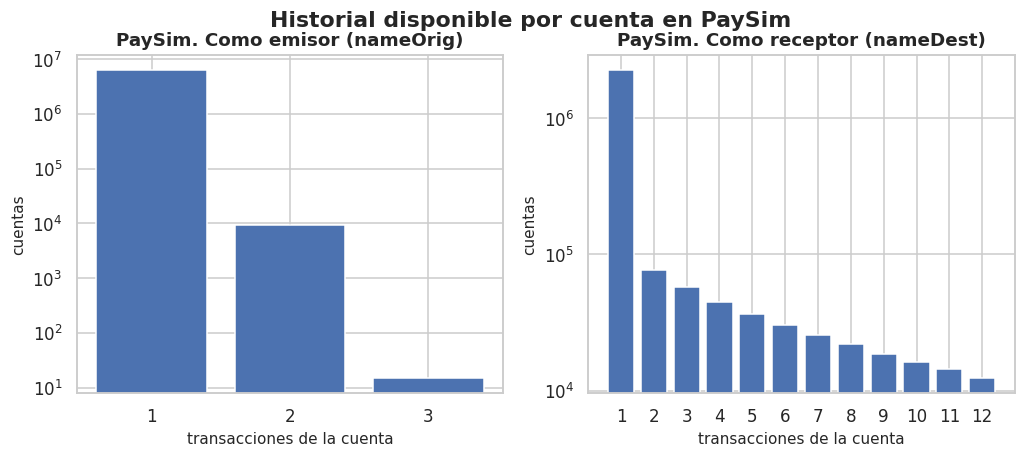

In [27]:
if conteos_paysim is not None:
    figura, ejes = plt.subplots(1, 2, figsize=(11, 4))
    for eje, columna, titulo in zip(
        ejes, ["nameOrig", "nameDest"],
        ["Como emisor (nameOrig)", "Como receptor (nameDest)"],
    ):
        cuentas_por_longitud = np.bincount(conteos_paysim[columna])[1:13]
        posiciones = np.arange(1, len(cuentas_por_longitud) + 1)
        eje.bar(posiciones, cuentas_por_longitud, color="#4C72B0")
        eje.set_title(f"PaySim. {titulo}")
        eje.set_xlabel("transacciones de la cuenta")
        eje.set_ylabel("cuentas")
        eje.set_yscale("log")
        eje.set_xticks(posiciones)
    figura.suptitle("Historial disponible por cuenta en PaySim", fontweight="bold")
    guardar("01_paysim_historial")
    plt.show()

### ¿Qué se observa?

El resultado es categórico. PaySim tiene **6,362,620 transacciones repartidas entre 6,353,307 cuentas emisoras distintas**, es decir **1.0015 transacciones por cuenta emisora**. El máximo histórico de cualquier cuenta es de **3 transacciones**, y solo el **0.15% de las cuentas emisoras aparece más de una vez**.

Una secuencia por remitente construida sobre PaySim tendría longitud uno en el 99.85% de los casos. No hay orden temporal que leer, ni frecuencia que medir, ni cambio de patrón que detectar.

Del otro lado, las **cuentas receptoras sí acumulan historial**. Hay 2,722,362 distintas, con 2.34 transacciones en promedio, un máximo de 113 y el 16.88% recibiendo más de una vez. Esa asimetría explica para qué sí sirve PaySim, que es detección a nivel de transacción y análisis de cuentas receptoras, que es exactamente para lo que se diseñó.

**Decisión.** PaySim se descarta como fuente de secuencias por remitente y el proyecto usa el conjunto de IBM, que sí las admite. PaySim se conserva en este cuaderno como la evidencia que sostiene esa decisión.

## 3. De transacciones a ventanas por remitente

El remitente no queda definido solo por el número de cuenta. Los identificadores hexadecimales se repiten entre bancos, así que la clave real es el par banco más cuenta. Con esa clave se cuenta cuántas transacciones envía cada remitente.

In [28]:
clave = (crudo["banco_emisor"].to_numpy().astype(np.int64) << 36) + crudo["cuenta_emisor"].to_numpy()
codigo = pd.factorize(clave, sort=False)[0]
transacciones_por_emisor = np.bincount(codigo)

etiqueta_emisor = np.zeros(transacciones_por_emisor.size, dtype=np.int8)
np.maximum.at(etiqueta_emisor, codigo, crudo["es_lavado"].to_numpy())

print(f"remitentes distintos : {transacciones_por_emisor.size:,}")
print(f"remitentes positivos : {int(etiqueta_emisor.sum()):,} ({etiqueta_emisor.mean():.4%})")
print("\npercentiles de transacciones por remitente")
print(pd.Series({f"p{p}": int(np.percentile(transacciones_por_emisor, p))
                 for p in (25, 50, 75, 90, 95, 99)}).to_string())
print(f"\nmaximo: {transacciones_por_emisor.max():,}")

remitentes distintos : 496,999
remitentes positivos : 3,376 (0.6793%)

percentiles de transacciones por remitente
p25     1
p50     2
p75     5
p90    29
p95    46
p99    92

maximo: 168,672


### ¿Qué se observa?

Hay **496,999 remitentes distintos** y la distribución de su actividad es muy desigual. La mediana envía **2 transacciones** y el percentil 75 llega a **5**, pero el percentil 90 salta a **29** y el máximo alcanza **168,672**. Ese valor extremo corresponde a una cuenta que funciona como concentrador institucional y no como un remitente individual.

A nivel de remitente, **3,376 tienen al menos una transacción marcada como lavado**, el 0.68%. La prevalencia sube respecto al 0.10% por transacción, porque un remitente sospechoso concentra varias transacciones marcadas.

La consecuencia práctica es que la mitad de los remitentes no tiene historial suficiente para formar una secuencia. Hay que fijar un mínimo.

In [29]:
filas = []
for minimo in (2, 3, 4, 5, 6, 8, 10):
    elegidos = transacciones_por_emisor >= minimo
    filas.append({
        "minimo de transacciones": minimo,
        "remitentes": int(elegidos.sum()),
        "positivos": int(etiqueta_emisor[elegidos].sum()),
        "prevalencia %": round(float(etiqueta_emisor[elegidos].mean()) * 100, 2),
        "transacciones cubiertas %": round(
            float(transacciones_por_emisor[elegidos].sum() / len(crudo)) * 100, 1),
    })
tabla_minimo = pd.DataFrame(filas).set_index("minimo de transacciones")
print(tabla_minimo.to_string())

                         remitentes  positivos  prevalencia %  transacciones cubiertas %
minimo de transacciones                                                                 
2                            344245       3254           0.95                       97.0
3                            185993       2758           1.48                       90.8
4                            142306       2085           1.47                       88.2
5                            128779       1626           1.26                       87.1
6                            122163       1437           1.18                       86.5
8                            115279       1255           1.09                       85.6
10                           110008       1185           1.08                       84.7


### ¿Qué se decide?

La tabla muestra el precio de cada umbral. Exigir **2 transacciones** conserva casi todos los positivos pero admite secuencias de longitud dos, donde no hay nada temporal que aprender. Exigir **5** deja los positivos en 1,626, una pérdida grande.

**Se fija el mínimo en 4 transacciones.** Conserva 142,306 remitentes y 2,085 positivos, cubre el 88.2% de las transacciones del archivo y alcanza una de las dos prevalencias más altas de la tabla. Frente al umbral de 3 se pierden 673 positivos, pero se gana que ninguna secuencia baje de cuatro pasos.

In [30]:
MINIMO = obtener("secuencias.minimo_transacciones")
LARGO = obtener("secuencias.longitud_maxima")

seleccionados = transacciones_por_emisor[transacciones_por_emisor >= MINIMO]
print(f"con al menos {MINIMO} transacciones quedan {seleccionados.size:,} remitentes")
print("percentiles de longitud:",
      {f"p{p}": int(np.percentile(seleccionados, p)) for p in (50, 75, 90, 95, 99)})
print(f"\nrecortando a distintas longitudes maximas")
for alternativa in (16, 24, 32, 48, 64):
    print(f"  L={alternativa:>3}  historial completo {(seleccionados <= alternativa).mean():>6.1%}"
          f"   pasos a procesar {np.minimum(seleccionados, alternativa).sum():>12,}")

con al menos 4 transacciones quedan 142,306 remitentes
percentiles de longitud: {'p50': 21, 'p75': 37, 'p90': 62, 'p95': 81, 'p99': 129}

recortando a distintas longitudes maximas
  L= 16  historial completo  41.9%   pasos a procesar    1,859,568
  L= 24  historial completo  60.1%   pasos a procesar    2,442,475
  L= 32  historial completo  70.5%   pasos a procesar    2,850,395
  L= 48  historial completo  83.6%   pasos a procesar    3,366,781
  L= 64  historial completo  91.0%   pasos a procesar    3,652,049


### ¿Qué se decide?

La longitud máxima decide cuánto historial ve el modelo y cuánto cuesta entrenarlo. La mediana de longitud es **21** y el percentil 95 es **81**, así que cubrir a casi todos exigiría secuencias cuatro veces más largas que la mediana.

**Se fija la longitud máxima en 32 pasos.** Con ese valor el **70.5% de los remitentes conserva su historial completo** y quedan 2,850,395 pasos por procesar. Subir a 48 agrega trece puntos de cobertura a cambio de un 18% más de cómputo, y subir a 64 agrega veinte puntos por un 28% más. Como el presupuesto es de treinta minutos en una GPU gratuita, el punto de 32 es el que mejor equilibra ambas cosas.

Del resto se conservan **las últimas 32 transacciones**, no las primeras. Un equipo de cumplimiento revisa el comportamiento reciente cuando abre una alerta, así que la ventana reciente es la que el sistema debe saber juzgar.

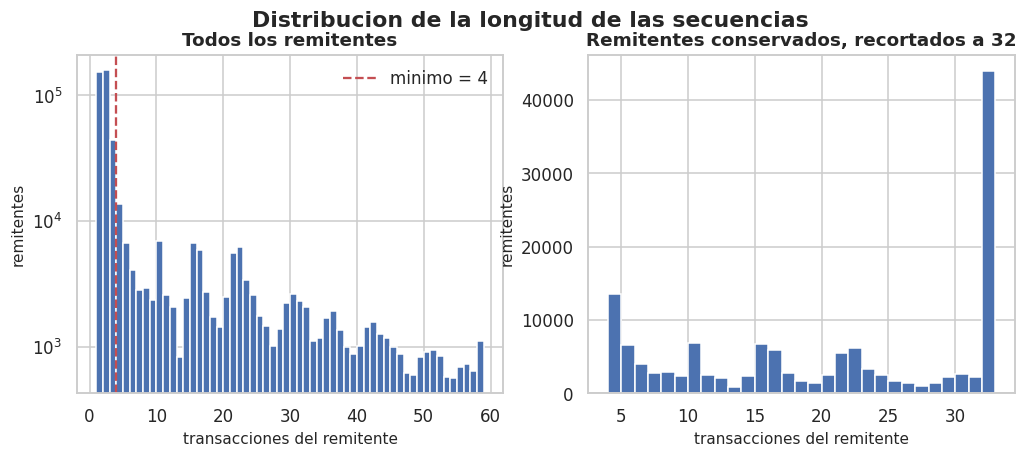

73350

In [31]:
figura, ejes = plt.subplots(1, 2, figsize=(11, 4))
ejes[0].hist(transacciones_por_emisor, bins=np.arange(1, 60), color="#4C72B0")
ejes[0].axvline(MINIMO, color="#C44E52", linestyle="--", label=f"minimo = {MINIMO}")
ejes[0].set_title("Todos los remitentes")
ejes[0].set_yscale("log")
ejes[0].legend()
ejes[1].hist(np.minimum(seleccionados, LARGO), bins=np.arange(MINIMO, LARGO + 2), color="#4C72B0")
ejes[1].set_title(f"Remitentes conservados, recortados a {LARGO}")
for eje in ejes:
    eje.set_xlabel("transacciones del remitente")
    eje.set_ylabel("remitentes")
figura.suptitle("Distribucion de la longitud de las secuencias", fontweight="bold")
guardar("01_longitudes")
plt.show()

del clave, codigo, seleccionados
gc.collect()

## 4. Las variables que describen cada transacción

Cada paso de la secuencia se describe con veinte variables. Todas se calculan dentro de la ventana observada y usando solo transacciones anteriores, de modo que ningún paso contiene información de su propio futuro.

Antes de calcularlas hay que resolver un problema de unidades. Los montos vienen expresados en quince monedas distintas, así que no son comparables entre sí. El propio conjunto de datos da la solución, porque las transacciones que cambian de moneda revelan la tasa implícita.

In [32]:
tasas = features.tasas_a_usd(crudo, catalogos)
ventana = features.construir_ventanas(crudo)
del crudo
gc.collect()

print(f"ventana : {len(ventana):,} transacciones de {ventana['emisor'].nunique():,} remitentes\n")
pd.Series(tasas, name="dolares por unidad").sort_values(ascending=False).to_frame()

ventana : 2,850,395 transacciones de 142,306 remitentes



,dolares por unidad
Bitcoin,11881.624023
UK Pound,1.291656
Euro,1.171783
Swiss Franc,1.092896
US Dollar,1.000000
Canadian Dollar,0.757978
Australian Dollar,0.707814
Shekel,0.296121
Saudi Riyal,0.266588
Brazil Real,0.177101


### ¿Qué se observa?

Las tasas derivadas del propio archivo son realistas para septiembre de 2022. El **bitcóin queda en 11,882 dólares**, la **libra en 1.29**, el **euro en 1.17** y el **yen en 0.0095**. Ninguna requiere una fuente externa, lo que evita introducir un supuesto que no se pueda verificar dentro del proyecto.

La tasa del bitcóin es la menos confiable porque se estima con muy pocas transacciones de cambio. Como el bitcóin aparece en el 3.1% de los pasos, el efecto sobre el conjunto es menor.

In [33]:
tabla = features.construir_variables(ventana, catalogos, tasas)
del ventana
gc.collect()

resumen_variables = pd.DataFrame(
    [{"media": tabla[nombre].mean(), "desviacion": tabla[nombre].std(),
      "minimo": tabla[nombre].min(), "maximo": tabla[nombre].max()}
     for nombre in features.VARIABLES],
    index=features.VARIABLES,
)
print(f"{len(features.VARIABLES)} variables sobre {len(tabla):,} transacciones")
resumen_variables.round(3)

20 variables sobre 2,850,395 transacciones


,media,desviacion,minimo,maximo
log_monto,6.945,2.767,0.000,23.534
log_delta_t,1.227,1.377,0.000,5.776
hora_sin,-0.005,0.681,-1.000,1.000
hora_cos,0.072,0.728,-1.000,1.000
dia_sin,0.078,0.626,-0.975,0.975
dia_cos,-0.356,0.686,-0.901,1.000
formato_ach,0.116,0.320,0.000,1.000
formato_bitcoin,0.031,0.173,0.000,1.000
formato_cash,0.092,0.294,0.000,1.000
formato_cheque,0.391,0.487,0.000,1.000


### ¿Qué se observa?

Las veinte variables se dividen en tres grupos. Cuatro son continuas y se normalizan más adelante, cuatro codifican hora y día del modo circular para que las once de la noche queden cerca de la medianoche, y doce son indicadores binarios.

Tres cifras del resumen ya dicen algo del negocio. El **91.9% de las transacciones cruza de banco**, así que operar entre entidades es lo normal y no una señal por sí misma. El **cheque es el formato dominante con 39.1%**, seguido de tarjeta de crédito con 29.1%. Y el **2.5% de las transacciones cae en la banda del 75 al 100% del umbral de reporte de diez mil dólares**, que es la zona donde se esperaría ver fraccionamiento.

La variable `desvio_monto` compara cada monto contra el promedio histórico del propio remitente dentro de su ventana. Su media es prácticamente cero por construcción, y su dispersión indica cuánto varía un remitente respecto de sí mismo.

## 5. Secuencias, etiquetas y desbalance

Con las variables listas, cada remitente se convierte en una matriz de 32 pasos por 20 variables. Los remitentes con menos de 32 transacciones se completan con ceros, y una máscara indica qué pasos son reales.

La etiqueta de un remitente es 1 si alguna transacción de su ventana está marcada como lavado.

In [34]:
tensores = secuencias.tensorizar(tabla, liberar=True)
del tabla
gc.collect()

print(f"X        : {tensores.X.shape}  {tensores.X.dtype}")
print(f"mascara  : {tensores.mascara.shape}")
print(f"y        : {tensores.y.shape}")
print(f"\nremitentes   : {len(tensores.y):,}")
print(f"positivos    : {int(tensores.y.sum()):,}")
print(f"prevalencia  : {tensores.y.mean():.4%}")
print(f"negativos por cada positivo: {(len(tensores.y) - tensores.y.sum()) / tensores.y.sum():.0f}")

X        : (142306, 32, 20)  float32
mascara  : (142306, 32)
y        : (142306,)

remitentes   : 142,306
positivos    : 1,947
prevalencia  : 1.3682%
negativos por cada positivo: 72


### ¿Qué se observa?

El tensor final tiene forma **(142,306 remitentes, 32 pasos, 20 variables)**. Quedan **1,947 remitentes positivos, el 1.37%**, es decir **72 remitentes normales por cada sospechoso**.

Es importante mencionar que antes de recortar la ventana había 2,085 remitentes positivos con al menos cuatro transacciones. **Recortar a 32 pasos deja 1,947, una pérdida de 138 remitentes, el 6.6%**. Son casos cuyas transacciones marcadas ocurrieron antes de sus últimas treinta y dos operaciones.

Esa pérdida es intencional. Etiquetar como positivo a un remitente cuya evidencia quedó fuera de la ventana obligaría al modelo a acertar sin haber visto nada, y produciría falsos negativos que no dependen de la calidad del modelo sino del recorte.

In [35]:
percentiles = [0.25, 0.5, 0.75, 0.9]
comparacion = pd.DataFrame({
    "normales": pd.Series(tensores.longitud[tensores.y == 0]).describe(percentiles=percentiles),
    "sospechosos": pd.Series(tensores.longitud[tensores.y == 1]).describe(percentiles=percentiles),
})
print(comparacion.round(1).to_string())

       normales  sospechosos
count  140359.0       1947.0
mean       20.1         15.8
std        10.5         11.4
min         4.0          4.0
25%        10.0          5.0
50%        21.0         12.0
75%        32.0         28.0
90%        32.0         32.0
max        32.0         32.0


### ¿Qué se observa?

Los remitentes sospechosos tienen **secuencias más cortas**. Su mediana es de **12 transacciones** frente a **21** en los normales, y su primer cuartil baja a 5 contra 10.

Esto tiene una implicación directa. Una cuenta usada para lavar dinero suele tener una vida operativa breve, mueve fondos y deja de usarse, mientras que una cuenta legítima acumula actividad de forma sostenida. El modelo deberá aprender a juzgar secuencias cortas sin que la longitud por sí sola se convierta en la única señal.

## 6. Partición sin filtración entre conjuntos

La unidad de partición es el remitente completo, nunca la transacción. Si una misma secuencia apareciera partida entre entrenamiento y prueba, el modelo vería en entrenamiento parte del comportamiento que después debe juzgar como nuevo, y las métricas quedarían infladas.

La partición se estratifica por etiqueta para que la prevalencia sea comparable en los tres conjuntos.

In [36]:
particion = splits.particionar(tensores.y)
escala = splits.ajustar_escala(tensores, particion.entrenamiento)
splits.aplicar_escala(tensores, escala)

print(pd.DataFrame(particion.resumen(tensores.y)).T.to_string())

solapamiento = (
    set(particion.entrenamiento) & set(particion.validacion)
    | set(particion.entrenamiento) & set(particion.prueba)
    | set(particion.validacion) & set(particion.prueba)
)
print(f"\nremitentes compartidos entre conjuntos: {len(solapamiento)}")
print("\nnormalizacion ajustada solo con entrenamiento")
print(pd.DataFrame({
    "variable": [features.VARIABLES[c] for c in escala.columnas],
    "media": escala.media.round(3),
    "desviacion": escala.desviacion.round(3),
}).to_string(index=False))

               remitentes  positivos  prevalencia
entrenamiento     99614.0     1363.0     0.013683
validacion        21346.0      292.0     0.013679
prueba            21346.0      292.0     0.013679

remitentes compartidos entre conjuntos: 0

normalizacion ajustada solo con entrenamiento
                variable  media  desviacion
               log_monto  6.949       2.769
             log_delta_t  1.226       1.377
log_repeticiones_destino  1.565       0.966
            desvio_monto -0.034       2.219


### ¿Qué se observa?

La partición deja **99,614 remitentes en entrenamiento, 21,346 en validación y 21,346 en prueba**, con **1,363, 292 y 292 positivos**. La prevalencia queda en **1.368% en los tres conjuntos**, y **ningún remitente aparece en más de uno**.

Solo se normalizan las cuatro variables continuas, y la media y la desviación se estiman **únicamente sobre los pasos reales del conjunto de entrenamiento**. Las variables binarias y las circulares ya están acotadas, así que estandarizarlas solo distorsionaría su interpretación.

Existe una limitación clara. Con **292 positivos en prueba**, cualquier métrica sobre esa clase tendrá un margen de error apreciable, del orden de tres puntos porcentuales en recall. Las conclusiones del segundo cuaderno tendrán en cuenta este margen de error.

Queda además una vía de filtración que esta partición no cierra. Los datos provienen de redes de lavado donde varias cuentas participan del mismo esquema. Separar por remitente evita que una misma secuencia se reparta, pero no impide que dos cuentas de la misma red caigan en conjuntos distintos.

## 7. Tres secuencias normales frente a tres sospechosas

Antes de modelar conviene mirar los datos. Se eligen tres remitentes normales y tres sospechosos de longitud parecida, y se dibuja cada secuencia como un mapa de calor donde las filas son variables y las columnas son pasos en el tiempo.

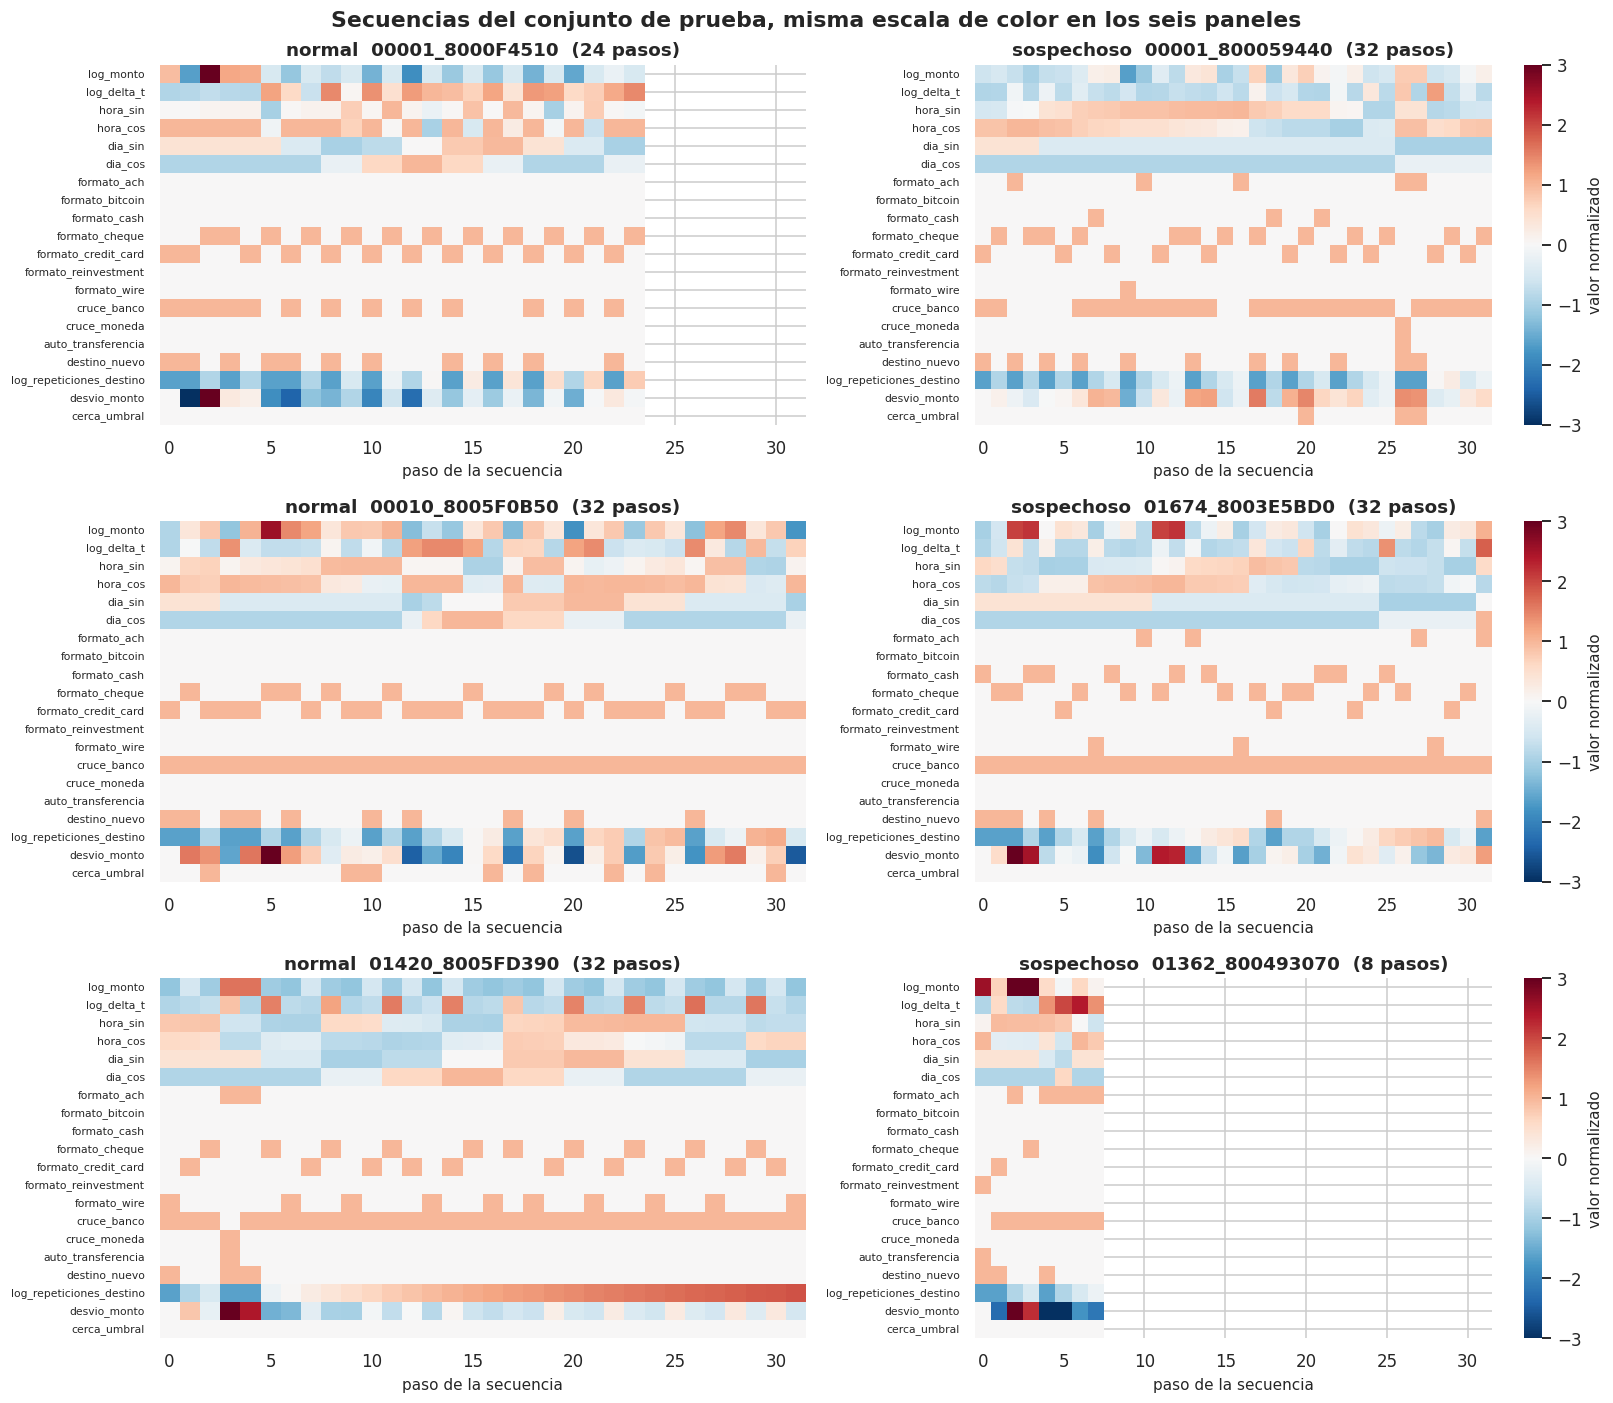

In [37]:
prueba = particion.prueba
largo_objetivo = (tensores.longitud[prueba] >= 8) & (tensores.longitud[prueba] <= LARGO)

sospechosos = prueba[(tensores.y[prueba] == 1) & largo_objetivo][:3]
normales = prueba[(tensores.y[prueba] == 0) & largo_objetivo][:3]

figura, ejes = plt.subplots(3, 2, figsize=(15, 13))
for fila, (normal, sospechoso) in enumerate(zip(normales, sospechosos)):
    for columna, (indice, etiqueta) in enumerate(
        [(normal, "normal"), (sospechoso, "sospechoso")]
    ):
        mapa_secuencia(
            tensores.X[indice], tensores.mascara[indice], tensores.variables,
            f"{etiqueta}  {tensores.identificador[indice]}  ({tensores.longitud[indice]} pasos)",
            eje=ejes[fila, columna],
            barra=columna == 1,
        )
figura.suptitle(
    "Secuencias del conjunto de prueba, misma escala de color en los seis paneles",
    fontweight="bold",
)
figura.tight_layout()
guardar("01_secuencias_normal_vs_sospechosa")
plt.show()

In [38]:
def perfil(indices: np.ndarray) -> pd.Series:
    """Promedio de cada variable sobre los pasos reales de un grupo de remitentes."""
    reales = np.zeros(tensores.mascara.shape, dtype=bool)
    reales[indices] = tensores.mascara[indices]
    return pd.Series(
        {nombre: float(tensores.X[:, :, i][reales].mean())
         for i, nombre in enumerate(tensores.variables)}
    )

contraste = pd.DataFrame({
    "normales": perfil(prueba[tensores.y[prueba] == 0]),
    "sospechosos": perfil(prueba[tensores.y[prueba] == 1]),
})
contraste["diferencia"] = contraste["sospechosos"] - contraste["normales"]
contraste.reindex(contraste["diferencia"].abs().sort_values(ascending=False).index).round(3)

,normales,sospechosos,diferencia
log_repeticiones_destino,-0.003,-0.267,-0.265
log_monto,-0.014,0.201,0.215
formato_ach,0.114,0.271,0.158
formato_credit_card,0.293,0.202,-0.091
destino_nuevo,0.168,0.254,0.086
auto_transferencia,0.058,0.121,0.063
formato_cheque,0.391,0.328,-0.063
cruce_banco,0.920,0.869,-0.051
hora_cos,0.074,0.025,-0.049
cruce_moneda,0.014,0.053,0.039


### ¿Qué se observa?

En los mapas de calor, con la escala unificada, se aprecian dos diferencias. Los remitentes sospechosos **alternan entre varios formatos de pago dentro de una misma ventana**, mientras que los normales repiten uno o dos. Y su fila `log_repeticiones_destino` es sistemáticamente **más azul**, es decir envían a destinos que casi no repiten, con `destino_nuevo` encendiéndose una y otra vez. El tercer panel normal muestra el contraste opuesto, su `log_repeticiones_destino` sube de forma sostenida hasta el rojo porque manda siempre al mismo destino.

El promedio sobre todo el conjunto de prueba confirma y ordena esas diferencias. Las cuatro variables continuas están normalizadas, así que sus valores se leen como desviaciones estándar. Las binarias se leen como proporciones.

| Señal | Normales | Sospechosos | Lectura |
| --- | --- | --- | --- |
| `log_repeticiones_destino` | -0.003 | -0.267 | Los sospechosos **repiten mucho menos sus destinos**, dispersan el dinero hacia contrapartes distintas |
| `log_monto` | -0.014 | 0.201 | Mueven **montos mayores** que el remitente típico |
| `formato_ach` | 11.4% | 27.1% | Usan **transferencias ACH al doble** de frecuencia |
| `destino_nuevo` | 16.8% | 25.4% | Una de cada cuatro operaciones va a un **destino nunca visto antes** |
| `auto_transferencia` | 5.8% | 12.1% | **Duplican** los movimientos entre cuentas propias |
| `cruce_moneda` | 1.4% | 5.3% | **Cambian de moneda casi cuatro veces más** |
| `cerca_umbral` | 2.5% | 4.5% | **Casi el doble de montos** en la banda previa al umbral de reporte |

Las dos primeras filas juntas describen el patrón de dispersión que la literatura llama fan-out, muchos destinos distintos y montos altos. La combinación de destinos nuevos, cambio de moneda y montos justo por debajo del umbral es el conjunto de señales que un analista buscaría a mano.

Ninguna de estas variables separa las clases por sí sola. El fraccionamiento bajo umbral sube del 2.5% al 4.5%, una diferencia real pero insuficiente para decidir. Ese es el argumento para modelar la secuencia completa en lugar de aplicar reglas sobre transacciones sueltas.

## 8. Decisiones tomadas y su efecto medido

| Decisión | Alternativas consideradas | Justificación | Efecto medido |
| --- | --- | --- | --- |
| Fuente de secuencias: IBM AML | PaySim, propuesto originalmente | En PaySim solo el 0.15% de las cuentas emisoras aparece más de una vez, con un máximo de 3 transacciones | 142,306 secuencias utilizables frente a ninguna |
| Remitente igual a banco más cuenta | Solo el número de cuenta | Los identificadores hexadecimales se repiten entre bancos | 496,999 remitentes bien definidos |
| Mínimo de 4 transacciones | 2, 3, 5, 6, 8, 10 | Es el menor umbral que garantiza cuatro pasos y conserva una prevalencia alta | 142,306 remitentes, 2,085 positivos, 88.2% de las transacciones |
| Longitud máxima de 32 | 16, 24, 48, 64 | Cubre el historial completo del 70.5% con un tercio del cómputo que exigiría el percentil 95 | 2,850,395 pasos, pérdida de 138 positivos |
| Conservar las últimas transacciones | Conservar las primeras | El comportamiento reciente es el que se revisa al abrir una alerta | Ventana alineada con el uso operativo |
| Tasas de cambio derivadas del archivo | Tabla externa de tipos de cambio | Las transacciones con cambio de moneda revelan la tasa implícita, sin supuestos externos | Quince monedas llevadas a una unidad común |
| Etiqueta dentro de la ventana | Etiqueta sobre el historial completo | Marcar como positivo a quien no muestra evidencia visible produciría falsos negativos artificiales | Prevalencia de 1.37% |
| Partición por remitente, estratificada | Partición por transacción | Una secuencia partida entre conjuntos inflaría las métricas | Cero remitentes compartidos, prevalencia igual en los tres |
| Normalización ajustada en entrenamiento | Ajustarla sobre todo el conjunto | Usar prueba para estimar la escala es filtración | Media y desviación de cuatro variables continuas |

## 9. Se guardan los tensores

El segundo cuaderno lee estos archivos en lugar de repetir el procesamiento. Si no los encuentra, reconstruye todo con las mismas funciones, de modo que ninguno de los dos cuadernos depende del otro para poder ejecutarse.

In [39]:
datos = construir.Datos(
    tensores=tensores, particion=particion, escala=escala,
    catalogos=catalogos, tasas=tasas,
)
construir.guardar_cache(datos)

verificacion = construir.verificar(datos)
for clave_resumen, valor in verificacion.items():
    print(f"{clave_resumen:>15}: {valor}")

     remitentes: 142306
  transacciones: 2850395
      positivos: 1947
    prevalencia: 0.01368178432392169
      variables: 20
      conjuntos: {'entrenamiento': {'remitentes': 99614, 'positivos': 1363, 'prevalencia': 0.013682815668480335}, 'validacion': {'remitentes': 21346, 'positivos': 292, 'prevalencia': 0.013679377869390049}, 'prueba': {'remitentes': 21346, 'positivos': 292, 'prevalencia': 0.013679377869390049}}


**Se conservan los artefactos**

Cuando el cuaderno corre en Colab, todo lo que escribe vive en una máquina virtual que se destruye al cerrar la sesión. Esta celda junta en un solo archivo el modelo, las figuras, las tablas y los datos del MVP, y lo descarga.

In [40]:
from utils.artefactos import empaquetar

if EN_COLAB:
    from google.colab import files

    archivo = empaquetar("artefactos_01")
    files.download(str(archivo))
else:
    print("Ejecucion local, los artefactos ya estan en su lugar.")

artefactos_01.zip: 4 archivos, 0.32 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 10. Conclusiones

- **PaySim no admite secuencias por remitente.** Sus 6,362,620 transacciones se reparten entre 6,353,307 cuentas emisoras distintas, con un máximo de 3 por cuenta.

- El conjunto de datos de IBM admite secuencias reales por remitente. De **496,999 remitentes**, **142,306 tienen al menos cuatro transacciones salientes** y suman **2,850,395 pasos** dentro de la ventana de 32.

- El problema es de **desbalance extremo**. Quedan **1,947 remitentes sospechosos frente a 140,359 normales**, es decir **72 a 1**. Cualquier modelo que prediga siempre la clase mayoritaria acierta el 98.6% de las veces sin ser útil, de modo que la exactitud queda descartada como métrica.

- Las secuencias sospechosas son **más cortas** que las normales, mediana de 12 contra 21 pasos, y se distinguen sobre todo por **dispersar el dinero hacia destinos que no repiten**, mover **montos mayores** y **cambiar de moneda** con más frecuencia.

- Ninguna variable separa las clases por sí sola. La señal más citada en cumplimiento, el fraccionamiento por debajo del umbral de reporte, pasa del **2.5% al 4.5%** de las transacciones. Es una diferencia real pero muy lejos de bastar para decidir, y por eso el sistema debe leer la secuencia completa.